In [2]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
import pickle
from tqdm import tqdm

In [3]:
DATASET_PATH = "./leapGestRecog"

TARGET_SIZE = (96, 96)
NUM_CLASSES = 8
TRAIN_RATIO = 0.7
CAL_RATIO = 0.15
TEST_RATIO = 0.15

CLASS_NAMES = {
    '00': 'palm',
    '01': '1',
    '02': 'fist',
    '03': 'thumb',
    '04': 'index',
    '05': 'ok',
    '06': 'c',
    '07': 'down'
}

In [4]:
def preprocess_image(image_path):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, TARGET_SIZE)
    normalized = resized.astype('float32') / 255.0
    return normalized

def augment_image(image):
    return image

test_img_path = os.path.join(
    DATASET_PATH,
    "00",
    "01_palm",
    "frame_00_01_0001.png"
)
if os.path.exists(test_img_path):
    test_result = preprocess_image(test_img_path)
    print("Shape of test_result:", test_result.shape)

Shape of test_result: (96, 96)


In [5]:
def collect_data():
    images = []
    labels = []
    gesture_folders = [
        '01_palm', '02_l', '03_fist', '05_thumb',
        '06_index', '07_ok', '09_c', '10_down'
    ]

    gesture_to_label = {
        '01_palm': 0,
        '02_l': 1,
        '03_fist': 2,
        '05_thumb': 3,
        '06_index': 4,
        '07_ok': 5,
        '09_c': 6,
        '10_down': 7
    }

    for class_dir in [f"{i:02d}" for i in range(10)]:
        class_path = os.path.join(DATASET_PATH, class_dir)

        for gesture_folder in gesture_folders:
            gesture_path = os.path.join(class_path, gesture_folder)
            if not os.path.exists(gesture_path):
                continue

            print(f"{class_dir}: {gesture_folder}")

            for img_name in tqdm(os.listdir(gesture_path)):
                if img_name.endswith('.png'):
                    img_path = os.path.join(gesture_path, img_name)
                    processed_img = preprocess_image(img_path)
                    images.append(processed_img)
                    labels.append(gesture_to_label[gesture_folder])

    return np.array(images), np.array(labels)

images, labels = collect_data()
print("\nFinish Collect data!")
print("Images Length: ", len(images))
print("Labels Length: ", len(labels))

00: 01_palm


100%|██████████| 200/200 [00:00<00:00, 324.24it/s]


00: 02_l


100%|██████████| 200/200 [00:00<00:00, 367.82it/s]


00: 03_fist


...

09: 09_c


100%|██████████| 200/200 [00:00<00:00, 421.04it/s]


09: 10_down


100%|██████████| 200/200 [00:00<00:00, 416.36it/s]



Finish Collect data!
Images Length:  16000
Labels Length:  16000


In [6]:
def split_and_save_data(images, labels):
    X_temp, X_test, y_temp, y_test = train_test_split(
        images,
        labels,
        test_size=TEST_RATIO,
        random_state=42,
        stratify=labels
    )

    X_train, X_cal, y_train, y_cal = train_test_split(
        X_temp,
        y_temp,
        test_size=CAL_RATIO/(TRAIN_RATIO + CAL_RATIO),
        random_state=42,
        stratify=y_temp
    )

    return {
        'train': (X_train, y_train),
        'cal': (X_cal, y_cal),
        'test': (X_test, y_test)
    }


datasets = split_and_save_data(images, labels)
print("Split and Save data Successfully!")

Split and Save data Successfully!


In [7]:
def verify_data(name, X, y):
    print(f"\nVerify {name} data:")
    assert len(X) == len(y), f"{name} hasn't the same X length and y length!"
    print(f"X has length: {len(X)}")

    for i in range(NUM_CLASSES):
        count = np.sum(y == i)
        print(f"{i} ({CLASS_NAMES[f'{i:02d}']}): {count}")
    
    return True

for name, (X, y) in datasets.items():
    verify_data(name, X, y)


Verify train data:
X has length: 11200
0 (palm): 1400
1 (1): 1400
2 (fist): 1400
3 (thumb): 1400
4 (index): 1400
5 (ok): 1400
6 (c): 1400
7 (down): 1400

Verify cal data:
X has length: 2400
0 (palm): 300
1 (1): 300
2 (fist): 300
3 (thumb): 300
4 (index): 300
5 (ok): 300
6 (c): 300
7 (down): 300

Verify test data:
X has length: 2400
0 (palm): 300
1 (1): 300
2 (fist): 300
3 (thumb): 300
4 (index): 300
5 (ok): 300
6 (c): 300
7 (down): 300


Extract .pkl files

In [8]:
for name, (X, y) in datasets.items():
    with open(f'{name}.pkl', 'wb') as f:
        pickle.dump((X, y), f)
    print(f'\nextract {name}.pkl successfully!')

print("\n Save all .pkl successfully!")


extract train.pkl successfully!

extract cal.pkl successfully!

extract test.pkl successfully!

 Save all .pkl successfully!


Validate shape

In [9]:
with open('train.pkl', 'rb') as f:
    X_train, y_train = pickle.load(f)

with open('cal.pkl', 'rb') as f:
    X_cal, y_cal = pickle.load(f)

with open('test.pkl', 'rb') as f:
    X_test, y_test = pickle.load(f)

print("X_train shape: ", X_train.shape)
print("y_train shape: ", y_train.shape)

X_train shape:  (11200, 96, 96)
y_train shape:  (11200,)


Load sample

Type:  float32
Range:  0.0  -  0.99607843
Shape:  (11200, 96, 96)
X_train with channel Shape:  (11200, 96, 96, 1)


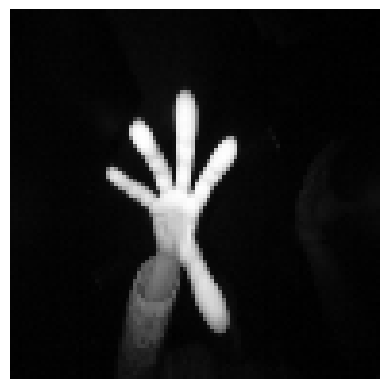

In [14]:
with open('train.pkl', 'rb') as f:
    X_train, y_train = pickle.load(f)

print("Type: ", X_train.dtype) # float32
print("Range: ", X_train.min(), " - ", X_train.max()) # 0-1
print("Shape: ", X_train.shape) # (15999, 96, 96)

X_train_with_channel = X_train[..., np.newaxis]
print("X_train with channel Shape: ", X_train_with_channel.shape) # (15999, 96, 96, 1)

import matplotlib.pyplot as plt
plt.imshow(X_train[1100], cmap='gray')
plt.axis('off')
plt.show()